Device: cpu
Dane juz istnieją
Dataset ImageFolder
    Number of datapoints: 4284
    Root location: ./data/Training
    StandardTransform
Transform: Compose(
               Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
               ToTensor()
               Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
           )
Dataset ImageFolder
    Number of datapoints: 1428
    Root location: ./data/Validation
    StandardTransform
Transform: Compose(
               Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
               ToTensor()
               Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
           )
Dataset ImageFolder
    Number of datapoints: 1311
    Root location: ./data/Testing
    StandardTransform
Transform: Compose(
               Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
               ToTensor()
               Normalize(mean=[0.485, 0

C:\Users\sosog\AppData\Roaming\Python\Python313\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\sosog\AppData\Roaming\Python\Python313\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Wczytano zapisany model
Trening zakończony. Najlepsza strata walidacyjna: inf
Test Loss: 0.0971
Test Accuracy: 96.95%

Classification Report:
              precision    recall  f1-score   support

      glioma       0.93      0.98      0.95       300
  meningioma       0.98      0.94      0.96       306
     notumor       0.99      1.00      1.00       405
   pituitary       0.98      0.95      0.96       300

    accuracy                           0.97      1311
   macro avg       0.97      0.97      0.97      1311
weighted avg       0.97      0.97      0.97      1311


Confusion Matrix:


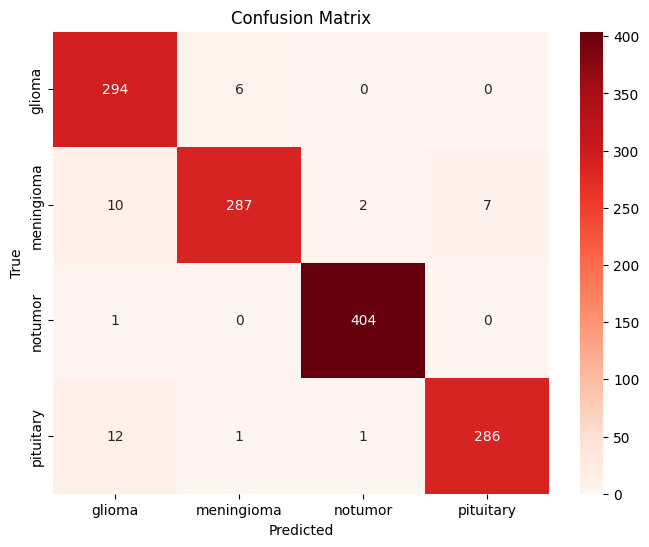

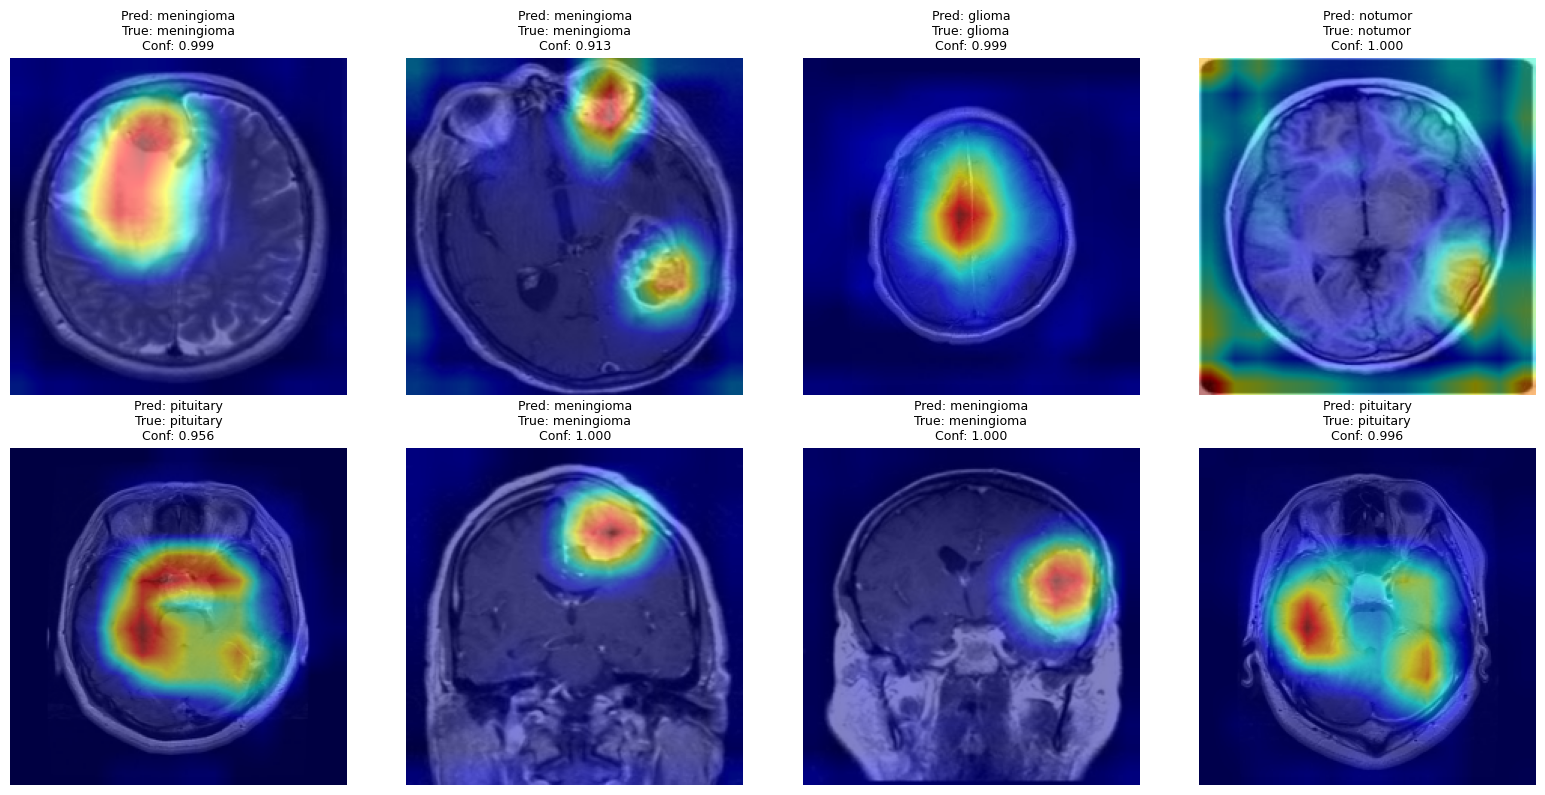

In [ ]:
import os
import shutil
from pathlib import Path
import kaggle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from PIL import Image
import random
from torchvision.models import vgg16
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torch.optim as optim
import torch.nn as nn
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image
import cv2
import torch.nn.functional as F
from pytorch_grad_cam import GradCAM

def load(tr_path):
    classes, class_paths = zip(*[(label, os.path.join(tr_path, label, image))
                                 for label in os.listdir(tr_path) if os.path.isdir(os.path.join(tr_path, label))
                                 for image in os.listdir(os.path.join(tr_path, label))])

    return pd.DataFrame({'Class Path': class_paths, 'Class': classes})

SEED = 900729
dir_path = './data'
train_path = './data/Training'
test_path = './data/Testing'
validation_path = './data/Validation'

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

if os.path.exists(dir_path):
    print("Dane juz istnieją")
else:
    kaggle.api.authenticate()
    kaggle.api.dataset_download_files('masoudnickparvar/brain-tumor-mri-dataset', path='./data', unzip=True)
    tr_orginal_df = load(train_path)
    ts_df = load(test_path)
    val_df, tr_df = train_test_split(tr_orginal_df, train_size=0.25, random_state=SEED, stratify=tr_orginal_df['Class'])
    validation_path = './data/Validation'
    Path(validation_path).mkdir(exist_ok=True)

    classes = ['glioma', 'meningioma', 'notumor', 'pituitary']
    for class_name in classes:
        class_validation_path = Path(validation_path) / class_name
        class_validation_path.mkdir(exist_ok=True)

    errors = []

    for idx, row in val_df.iterrows():
        try:
            source_path = Path(row['Class Path'])
            filename = source_path.name
            class_name = row['Class']
            destination_path = Path(validation_path) / class_name / filename
            shutil.move(str(source_path), str(destination_path))
        except Exception as e:
            errors.append({
                'file': row['Class Path'],
                'class': row['Class'],
                'error': str(e)
            })

    if errors:
        print(f"Errors: {len(errors)}")
        for error in errors:
            print(f"  - {error['class']}: {Path(error['file']).name} - {error['error']}")

    print("Pomyślnie pobrano i przygotowano dane")


data_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_dataset = datasets.ImageFolder(root=train_path, transform=data_transform)
test_dataset  = datasets.ImageFolder(root=test_path, transform=data_transform)
val_dataset   = datasets.ImageFolder(root=validation_path, transform=data_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False)
val_loader   = DataLoader(val_dataset, batch_size=32, shuffle=False)

print(train_dataset)
print(val_dataset)
print(test_dataset)

model = vgg16(pretrained=True)

num_features = model.classifier[6].in_features
model.classifier[6] = nn.Linear(num_features, len(train_dataset.classes))

model = model.to(device)

optimizer = optim.Adam(model.parameters(), lr=0.0001)
criterion = nn.CrossEntropyLoss()

EPOCHS = 10
best_val_loss = float('inf')
model_path = 'best_model_VGG16.pth'

if os.path.exists(model_path):
    model.load_state_dict(torch.load(model_path))
    print("Wczytano zapisany model")
else:
    for epoch in range(EPOCHS):
        model.train()
        running_loss = 0.0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * inputs.size(0)

        epoch_loss = running_loss / len(train_loader.dataset)

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
                for imgs, labels in val_loader:
                    imgs, labels = imgs.to(device), labels.to(device)
                    outputs = model(imgs)
                    loss = criterion(outputs, labels)
                    val_loss += loss.item()

        val_loss /= len(val_loader)

        print(f"Epoch {epoch+1}/{EPOCHS}, Loss: {epoch_loss:.4f}, Val Loss: {val_loss:.4f}")
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), model_path)
            print(f"Zapisano nowy najlepszy model z stratą walidacyjną: {val_loss:.4f}")

model.load_state_dict(torch.load(model_path))
print(f"Trening zakończony. Najlepsza strata walidacyjna: {best_val_loss:.4f}")

model.eval()
test_loss = 0.0
correct = 0
total = 0
all_labels = []
all_predictions = []

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        test_loss += loss.item()

        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        all_labels.extend(labels.cpu().numpy())
        all_predictions.extend(predicted.cpu().numpy())

test_loss /= len(test_loader)
accuracy = 100 * correct / total

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {accuracy:.2f}%")

print("\nClassification Report:")
print(classification_report(all_labels, all_predictions, target_names=test_dataset.classes))

print("\nConfusion Matrix:")
cm = confusion_matrix(all_labels, all_predictions)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', xticklabels=test_dataset.classes, yticklabels=test_dataset.classes)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

target_layers = [model.features[28]]
cam = GradCAM(model=model, target_layers=target_layers)

samples = random.sample(test_dataset.samples, 8)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for ax, (img_path, true_label) in zip(axes.flatten(), samples):
    img = cv2.imread(img_path, 1)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img, (224, 224))
    rgb_img = np.float32(img_resized) / 255

    input_tensor = data_transform(Image.fromarray(img_resized)).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(input_tensor)
        predicted_class = outputs.argmax(dim=1).item()
        probabilities = F.softmax(outputs, dim=1)[0]

    targets = [ClassifierOutputTarget(predicted_class)]
    grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0, :]
    visualization = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)

    ax.imshow(visualization)
    ax.set_title(
        f"Pred: {test_dataset.classes[predicted_class]}\nTrue: {test_dataset.classes[true_label]}\nConf: {probabilities[predicted_class]:.3f}",
        fontsize=9
    )
    ax.axis("off")

plt.tight_layout()
plt.show()